In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from transformers import DeiTModel
from PIL import Image
from tqdm import tqdm
import os
import time
from google.colab import drive

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(26)
np.random.seed(26)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device Used for computation: ')
print(device)

# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')),  # Ensure RGB format
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')),  # Ensure RGB format
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset preparation
class ApplyTransform(Dataset):
    """Apply transformations to a subset"""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Configuration
drive.mount('/content/drive')
# folder path
data_dir = '/content/drive/My Drive/SURE Summer 2022/Full_data'
full_dataset = datasets.ImageFolder(data_dir, transform=None)  # No initial transform

# Stratified split
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    stratify=full_dataset.targets,
    random_state=26
)

# Create subsets with transforms
train_subset = ApplyTransform(Subset(full_dataset, train_idx), train_transform)
val_subset = ApplyTransform(Subset(full_dataset, val_idx), val_transform)

# Data loaders
batch_size = 16
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_subset)}, Validation samples: {len(val_subset)}")
print(f"Class names: {full_dataset.classes}")

Device Used for computation: 
cuda
Mounted at /content/drive
Train samples: 2140, Validation samples: 536
Class names: ['bainite', 'martensite']


In [ ]:
# Model definition
class DeiTBinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.deit = DeiTModel.from_pretrained('facebook/deit-base-distilled-patch16-224')
        self.classifier = nn.Sequential(
            nn.Linear(self.deit.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        outputs = self.deit(pixel_values=x)
        cls_token = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_token).squeeze()

model = DeiTBinaryClassifier().to(device)

# Freeze base model initially
for param in model.deit.parameters():
    param.requires_grad = False

# Training parameters
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW([
    {'params': model.classifier.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
early_stop_patience = 4
best_val_loss = float('inf')
epochs_no_improve = 0

# Training variables
num_epochs = 25
train_losses = []
val_losses = []
train_accs = []
val_accs = []

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/349M [00:00<?, ?B/s]

Some weights of DeiTModel were not initialized from the model checkpoint at facebook/deit-base-distilled-patch16-224 and are newly initialized: ['deit.pooler.dense.bias', 'deit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Initial training of classifier head:


Epoch 25/25 [Val]: 100%|██████████| 34/34 [00:01<00:00, 19.33it/s, val_loss=0.0358, val_acc=0.985]



Training complete in 5m 47s
Best validation loss: 0.0358

Starting full model fine-tuning...
Loaded best model for fine-tuning


Epoch 6/15 [Val]: 100%|██████████| 34/34 [00:01<00:00, 19.08it/s, val_loss=0.0117, val_acc=0.998]



Early stopping triggered after 6 epochs!

Training complete in 1m 54s
Best validation loss: 0.0011
Training complete in 7m 42s
Best validation loss: inf


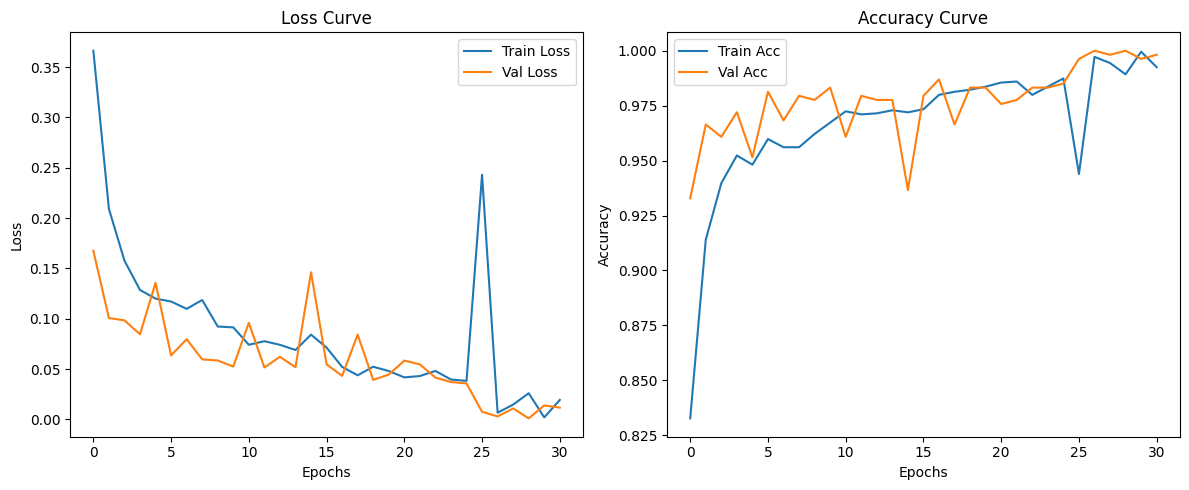

In [ ]:
# ========================================= training + fine-tuning =======================================================

# Modified training loop with progress bar and fine-tuning capability
def train_model(model, optimizer, scheduler, num_epochs, early_stop_patience=3, fine_tune=False):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # Load best model if fine-tuning
    if fine_tune:
        model.load_state_dict(torch.load('best_model.pth', weights_only=True))
        print("Loaded best model for fine-tuning")

    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device).float()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Update progress bar
            train_bar.set_postfix({
                'loss': running_loss / total,
                'acc': correct / total
            })

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device).float()

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_running_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                val_bar.set_postfix({
                    'val_loss': val_running_loss / val_total,
                    'val_acc': val_correct / val_total
                })

        val_epoch_loss = val_running_loss / val_total
        val_epoch_acc = val_correct / val_total
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)

        # Update scheduler
        scheduler.step(val_epoch_loss)

        # Early stopping check
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f'\nEarly stopping triggered after {epoch+1} epochs!')
                break

    total_time = time.time() - start_time
    print(f'\nTraining complete in {total_time//60:.0f}m {total_time%60:.0f}s')
    print(f'Best validation loss: {best_val_loss:.4f}')

    return history

# Initial training (classifier only)
start_time = time.time()
print("Initial training of classifier head:")
initial_history = train_model(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    early_stop_patience=early_stop_patience
)

# Fine-tuning after early stopping
print("\nStarting full model fine-tuning...")
# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

# Create new optimizer with lower learning rate
fine_tune_optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,  # Lower learning rate for fine-tuning
    weight_decay=1e-5
)

# New scheduler for fine-tuning
fine_tune_scheduler = lr_scheduler.ReduceLROnPlateau(
    fine_tune_optimizer,
    'min',
    patience=2,
    factor=0.5
)

# Run fine-tuning
fine_tune_history = train_model(
    model=model,
    optimizer=fine_tune_optimizer,
    scheduler=fine_tune_scheduler,
    num_epochs=15,  # Fewer epochs for fine-tuning
    early_stop_patience=2,  # More aggressive early stopping
    fine_tune=True
)

# Combine histories for plotting
combined_history = {
    'train_loss': initial_history['train_loss'] + fine_tune_history['train_loss'],
    'val_loss': initial_history['val_loss'] + fine_tune_history['val_loss'],
    'train_acc': initial_history['train_acc'] + fine_tune_history['train_acc'],
    'val_acc': initial_history['val_acc'] + fine_tune_history['val_acc']
}

# Plotting code remains the same, using combined_history
# After training
total_time = time.time() - start_time
print(f'Training complete in {total_time//60:.0f}m {total_time%60:.0f}s')
print(f'Best validation loss: {best_val_loss:.4f}')

# Save the model's state_dict using torch.save
torch.save(model.state_dict(), '/content/drive/My Drive/SURE Summer 2022/best_DeiT_model.pth')

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(combined_history['train_loss'], label='Train Loss')
plt.plot(combined_history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(combined_history['train_acc'], label='Train Acc')
plt.plot(combined_history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Some weights of DeiTModel were not initialized from the model checkpoint at facebook/deit-base-distilled-patch16-224 and are newly initialized: ['deit.pooler.dense.bias', 'deit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Prediction for: /content/drive/My Drive/SURE Summer 2022/Test_image/bainite/om3.png
Predicted class: martensite
Probabilities:
- bainite: 0.0000
- martensite: 1.0000


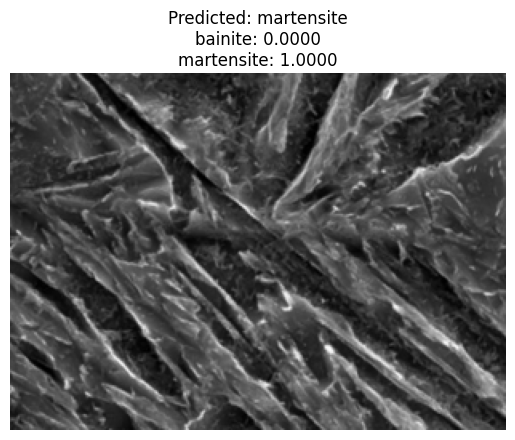

In [ ]:
# Load the best model
model = DeiTBinaryClassifier()
model.load_state_dict(torch.load('/content/drive/My Drive/SURE Summer 2022/best_DeiT_model.pth', map_location=device, weights_only=True))
model.to(device)
model.eval()

# Get class names from the dataset
class_names = full_dataset.classes

# Define test transformation (same as validation)
test_transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_image(image_path, model, transform, class_names):
    """
    Predict class and probabilities for a single image
    Returns: (predicted_class, probabilities_dict)
    """
    # Load and transform image
    img = Image.open(image_path)
    img = transform(img).unsqueeze(0).to(device)  # Add batch dimension

    # Make prediction
    with torch.no_grad():
        output = model(img)
        probability = torch.sigmoid(output).item()

    # Get probabilities for both classes
    prob_class_0 = 1 - probability
    prob_class_1 = probability

    # Create probabilities dictionary
    probabilities = {
        class_names[0]: prob_class_0,
        class_names[1]: prob_class_1
    }

    # Get predicted class
    predicted_class = class_names[0] if prob_class_0 > prob_class_1 else class_names[1]

    return predicted_class, probabilities

# Example usage
#test_image_path = '/content/drive/My Drive/SURE Summer 2022/Test_image/martensite/martensite1.png'
test_image_path = '/content/drive/My Drive/SURE Summer 2022/Test_image/bainite/om3.png'
# Make prediction
pred_class, probs = predict_image(test_image_path, model, test_transform, class_names)

# Print results
print(f"\nPrediction for: {test_image_path}")
print(f"Predicted class: {pred_class}")
print("Probabilities:")
for cls_name, prob in probs.items():
    print(f"- {cls_name}: {prob:.4f}")

# Optional: Visualization
def show_prediction(image_path, pred_class, probs):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    title = f"Predicted: {pred_class}\n"
    title += "\n".join([f"{k}: {v:.4f}" for k, v in probs.items()])
    plt.title(title)
    plt.show()

show_prediction(test_image_path, pred_class, probs)

In [ ]:
# ======================================================= checks for overfitting during model's training phase =============================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

def check_overfitting(history):
    """Analyze training history for overfitting patterns"""
    # Calculate metrics differences
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
    acc_diff = final_train_acc - final_val_acc

    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]
    loss_diff = final_val_loss - final_train_loss

    print("\nOverfitting Analysis:")
    print(f"Final Train Accuracy: {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"Accuracy Difference (Train - Val): {acc_diff:.4f}")
    print(f"\nFinal Train Loss: {final_train_loss:.4f}")
    print(f"Final Validation Loss: {final_val_loss:.4f}")
    print(f"Loss Difference (Val - Train): {loss_diff:.4f}")

    # Check for warning signs
    warning_threshold = 0.15
    if acc_diff > warning_threshold:
        print(f"\n⚠️ Warning: Large accuracy difference ({acc_diff:.2f}) detected!")
    if final_val_loss > final_train_loss:
        print("⚠️ Warning: Validation loss higher than training loss!")
    if history['val_loss'].index(min(history['val_loss'])) < len(history['val_loss'])-3:
        print("⚠️ Warning: Validation loss stopped improving early!")

def evaluate_model(model, dataloader, device):
    """Evaluate model on given dataloader and return predictions"""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.float().to(device)

            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)

    return all_labels, all_preds, all_probs

def plot_metrics_comparison(y_true_train, y_pred_train, y_true_val, y_pred_val, class_names):
    """Plot comparative metrics between training and validation sets"""
    plt.figure(figsize=(18, 6))

    # Confusion matrices
    plt.subplot(1, 3, 1)
    cm_train = confusion_matrix(y_true_train, y_pred_train)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Training Set Confusion Matrix')

    plt.subplot(1, 3, 2)
    cm_val = confusion_matrix(y_true_val, y_pred_val)
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Validation Set Confusion Matrix')

    # Classification reports
    plt.subplot(1, 3, 3)
    report_train = classification_report(y_true_train, y_pred_train,
                                       target_names=class_names, output_dict=True)
    report_val = classification_report(y_true_val, y_pred_val,
                                      target_names=class_names, output_dict=True)

    metrics = ['precision', 'recall', 'f1-score']
    classes = class_names + ['accuracy'] # classes is 2 + overall = 3

    for i, metric in enumerate(metrics):
        train_vals = [report_train[c][metric] for c in class_names] + [report_train['accuracy']]
        val_vals = [report_val[c][metric] for c in class_names] + [report_val['accuracy']]

        positions = np.arange(len(classes)) + i*0.2 # 3 ticks
        plt.bar(positions - 0.1, train_vals, width=0.2, label=f'Train {metric}')
        plt.bar(positions + 0.1, val_vals, width=0.2, label=f'Val {metric}')

    plt.xticks(np.arange(len(classes)) + 0.2, classes) # Remove the +['Overall'] so the number of labels matches the number of ticks
    plt.ylim(0, 1.1)
    plt.title('Metric Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run overfitting checks
check_overfitting(combined_history)

# Evaluate on both training and validation sets
print("\nEvaluating on training set...")
train_labels, train_preds, train_probs = evaluate_model(model, train_loader, device)

print("\nEvaluating on validation set...")
val_labels, val_preds, val_probs = evaluate_model(model, val_loader, device)

class_names = full_dataset.classes
# Plot comparative metrics
plot_metrics_comparison(train_labels, train_preds,
                        val_labels, val_preds,
                        class_names=class_names)

# Additional statistical checks
print("\nClassification Report - Training Set:")
print(classification_report(train_labels, train_preds, target_names=class_names))

print("\nClassification Report - Validation Set:")
print(classification_report(val_labels, val_preds, target_names=class_names))

NameError: name 'combined_history' is not defined


Evaluating on Test Set...


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 13.55it/s]



Test Accuracy: 1.0000
ROC AUC: 1.0000
PR AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

     bainite       1.00      1.00      1.00        87
  martensite       1.00      1.00      1.00        93

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



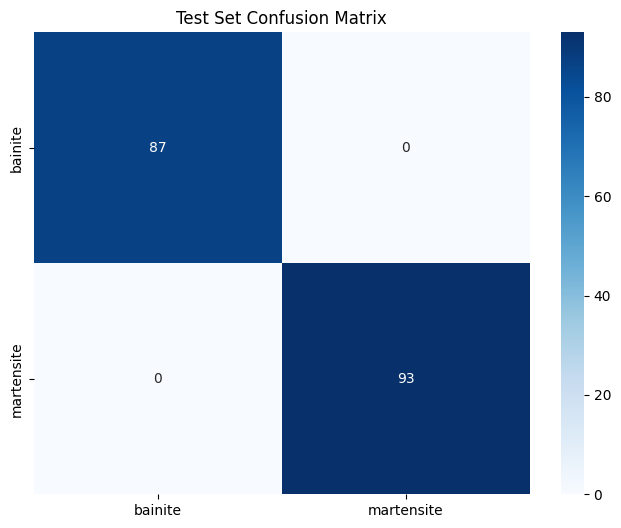

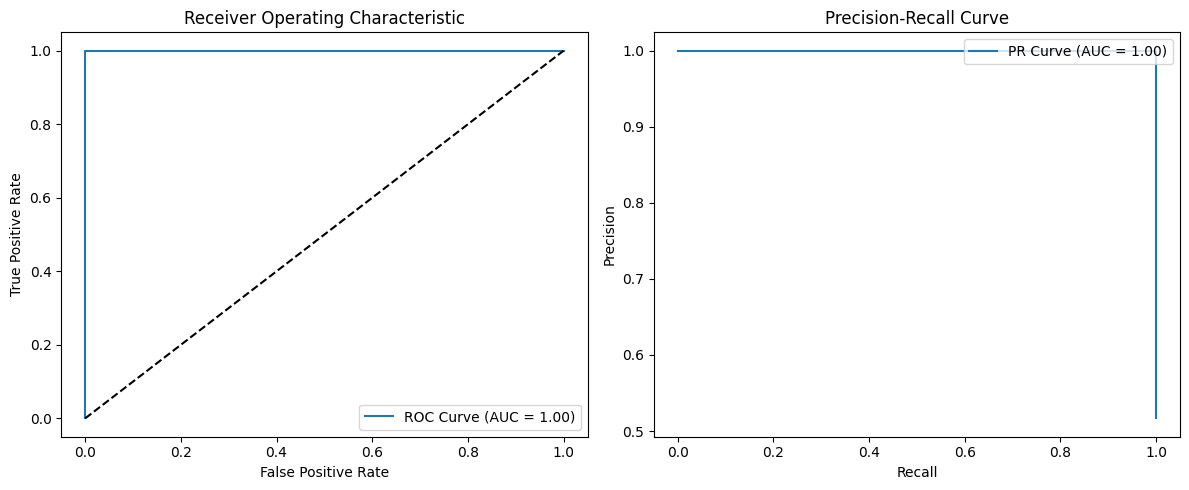


Overfitting Analysis:


NameError: name 'combined_history' is not defined

In [ ]:
# =================================================== test phase performance ====================================================
# Add these imports at the top with other imports
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Load and prepare test dataset
test_dir = '/content/drive/My Drive/SURE Summer 2022/Test_image'
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Load the best model
model.load_state_dict(torch.load('/content/drive/My Drive/SURE Summer 2022/best_DeiT_model.pth', map_location=device, weights_only=True))
model.to(device)
model.eval()

def evaluate_test_set(model, test_loader, device, class_names):
    """Evaluate model on test set and return comprehensive metrics"""
    # Get predictions and labels
    all_labels, all_preds, all_probs = evaluate_model(model, test_loader, device)

    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Calculate metrics
    accuracy = np.mean(all_labels == all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)

    # ROC Curve metrics
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall, precision)

    return {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'fpr': fpr,
        'tpr': tpr,
        'precision': precision,
        'recall': recall,
        'probs': all_probs,
        'labels': all_labels
    }

# Evaluate on test set
print("\nEvaluating on Test Set...")
test_metrics = evaluate_test_set(model, test_loader, device, class_names)

# Print basic metrics
print(f"\nTest Accuracy: {test_metrics['accuracy']:.4f}")
print(f"ROC AUC: {test_metrics['roc_auc']:.4f}")
print(f"PR AUC: {test_metrics['pr_auc']:.4f}")
print("\nClassification Report:")
print(classification_report(test_metrics['labels'], (test_metrics['probs'] > 0.5).astype(int),
      target_names=class_names))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(test_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Test Set Confusion Matrix')
plt.show()

# Plot ROC and PR curves
plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(test_metrics['fpr'], test_metrics['tpr'], label=f'ROC Curve (AUC = {test_metrics["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(test_metrics['recall'], test_metrics['precision'], label=f'PR Curve (AUC = {test_metrics["pr_auc"]:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Overfitting analysis comparison
print("\nOverfitting Analysis:")
print(f"Training Accuracy: {combined_history['train_acc'][-1]:.4f}")
print(f"Validation Accuracy: {combined_history['val_acc'][-1]:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"\nTraining Loss: {combined_history['train_loss'][-1]:.4f}")
print(f"Validation Loss: {combined_history['val_loss'][-1]:.4f}")

# Calculate test loss
test_loss = 0.0
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).float()
        outputs = model(inputs)
        test_loss += criterion(outputs, labels).item() * inputs.size(0)

test_loss /= len(test_dataset)
print(f"Test Loss: {test_loss:.4f}")